PART A – CONCEPTUAL FOUNDATION

#
Q1. What is Data Analysis?

--Answer--


Data Analysis is the process of collecting, cleaning, transforming, and interpreting data to discover useful information and support decision-making.

In simple words:

Raw data → Meaningful Insights → Better Decisions

Steps in Data Analysis
Data Collection
Data Cleaning
Data Exploration
Data Visualization
Statistical Analysis
Interpretation
Decision Making
Example

A bank wants to know why customers default on loans.
#

####
Q2. How to Plan a Data Science Project?
---
Answer--
CRISP-DM Framework
1. Business Understanding

Understand the problem.

Example:

Predict whether a customer will default on a loan.

2. Data Understanding

Explore available data.

Example:

df.info()
df.describe()
3. Data Preparation

Clean and preprocess data.

Tasks:

Missing values
Outliers
Encoding
Scaling
4. Modeling

Train ML models.

Examples:

Logistic Regression
Random Forest
XGBoost
5. Evaluation

Check model performance.

Metrics:

Accuracy
Precision
Recall
F1 Score
6. Deployment

Deploy model into production.

Examples:

Flask
FastAPI
Streamlit
Q3. How to Frame a Machine Learning Problem?
Step 1: Define Business Problem

Business Question:

Will a customer default on a loan?

Step 2: Define Target Variable
default_flag

0 = No Default
1 = Default
Step 3: Identify Features

Input Variables:

age
annual_income
credit_score
loan_amount
employment_type
repayment_history
Step 4: Determine ML Type

Target has:

0
1

Therefore:

Binary Classification Problem

Step 5: Success Metrics

Examples:

Accuracy,
Precision,
Recall,
ROC-AUC,
-----------------

Q2. TENSORS 
What is a Tensor?

A Tensor is a mathematical structure used to store data in multiple dimensions.

You can think of it as:

Scalar → 0D Tensor
Vector → 1D Tensor
Matrix → 2D Tensor
Multi-dimensional Array → Tensor
Tensor Hierarchy
0-D Tensor (Scalar)

Single Value

import numpy as np

a = np.array(10)

print(a)

Output:

10

Shape:

a.shape

Output:

()
1-D Tensor (Vector)
arr = np.array([1,2,3,4])

Representation:

[1 2 3 4]

Shape:

(4,)
2-D Tensor (Matrix)
arr = np.array([
    [1,2],
    [3,4]
])

Output:

[[1 2]
 [3 4]]

Shape:

(2,2)
3-D Tensor
arr = np.array([
[
 [1,2],
 [3,4]
],
[
 [5,6],
 [7,8]
]
])

Shape:

(2,2,2)

Think:

2 Matrices
↓
Each Matrix = 2 Rows
↓
Each Row = 2 Values
Why Tensors Matter in AI?

Every Deep Learning model works on tensors.

Examples:

Image
Height × Width × Channels

Example:

224 × 224 × 3

RGB:

Red
Green
Blue
Video
Frames × Height × Width × Channels

Example:

100 × 224 × 224 × 3
Text

Words are converted into tensors before entering Neural Networks.

Example:

I Love AI

Converted into:

[101,202,303]
####

PART B – DATA ACQUISITION

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import requests
import json

In [5]:
df_csv = pd.read_csv("Customer_Credit_Risk_Uncleaned_Dataset.csv")

print(df_csv.head())

  customer_id   age  gender region education_level employment_type  \
0    CUST1000  59.0    Male  North        Graduate        Salaried   
1    CUST1001  49.0  Female   East   Post-Graduate        Salaried   
2    CUST1002  35.0    Male   East         Primary             NaN   
3    CUST1003  63.0     NaN   West         Primary        Salaried   
4    CUST1004  28.0    Male   West        Graduate        Salaried   

   annual_income  loan_amount loan_purpose  credit_score  repayment_history  \
0      406562.59    309942.47         Home         767.0                  2   
1      206847.47    192947.24     Business           NaN                  0   
2      850861.45    177230.96     Business         550.0                  1   
3      863041.70    525509.20     Business           NaN                  1   
4      435290.31    434658.02    Education         689.0                  0   

   transaction_count  spending_ratio   join_date  default_flag  
0                290           24.29  2

In [6]:
customer_json = [
    {
        "customer_id":"CUST1001",
        "marital_status":"Married",
        "dependents":2
    },
    {
        "customer_id":"CUST1002",
        "marital_status":"Single",
        "dependents":0
    }
]
df_json = pd.DataFrame(customer_json)

print(df_json.head())

  customer_id marital_status  dependents
0    CUST1001        Married           2
1    CUST1002         Single           0


In [7]:
conn = sqlite3.connect("loan_history.db")

In [8]:
url = "https://dummyjson.com/products/1"

response = requests.get(url)

data = response.json()

print(data)

{'id': 1, 'title': 'Essence Mascara Lash Princess', 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.', 'category': 'beauty', 'price': 9.99, 'discountPercentage': 10.48, 'rating': 2.56, 'stock': 99, 'tags': ['beauty', 'mascara'], 'brand': 'Essence', 'sku': 'BEA-ESS-ESS-001', 'weight': 4, 'dimensions': {'width': 15.14, 'height': 13.08, 'depth': 22.99}, 'warrantyInformation': '1 week warranty', 'shippingInformation': 'Ships in 3-5 business days', 'availabilityStatus': 'In Stock', 'reviews': [{'rating': 3, 'comment': 'Would not recommend!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Eleanor Collins', 'reviewerEmail': 'eleanor.collins@x.dummyjson.com'}, {'rating': 4, 'comment': 'Very satisfied!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Lucas Gordon', 'reviewerEmail': 'lucas.gordon@x.dummyjson.com'}, {'rating': 5, 'comment': '

In [9]:
df = df_csv.copy()

In [10]:
df = pd.merge(
    df,
    df_json,
    on="customer_id",
    how="left"
)

In [11]:
print(df.shape)

(500, 17)


##
Part C – Data Understanding & Cleaning
##

In [12]:
import pandas as pd

df = pd.read_csv("Customer_Credit_Risk_Uncleaned_Dataset.csv")

In [13]:
df.shape

(500, 15)

In [14]:
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST1000,59.0,Male,North,Graduate,Salaried,406562.59,309942.47,Home,767.0,2,290,24.29,2022-07-03,0
1,CUST1001,49.0,Female,East,Post-Graduate,Salaried,206847.47,192947.24,Business,NaN,0,40,53.54,2019-09-20,0
2,CUST1002,35.0,Male,East,Primary,NaN,850861.45,177230.96,Business,550.0,1,221,51.43,2019-08-27,0
3,CUST1003,63.0,NaN,West,Primary,Salaried,863041.70,525509.20,Business,NaN,1,84,63.13,2021-03-07,0
4,CUST1004,28.0,Male,West,Graduate,Salaried,435290.31,434658.02,Education,689.0,0,87,90.43,2021-12-16,1


In [15]:
df.tail()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
495,CUST1495,33.0,Male,North,Graduate,Self-Employed,697321.97,365350.64,Other,578.0,2,127,74.29,2019-01-11,0
496,CUST1496,32.0,Female,South,Primary,NaN,NaN,495600.73,Car,780.0,3,140,77.50,2024-07-24,0
497,CUST1497,51.0,Male,West,Primary,Unemployed,771490.57,448363.48,Other,697.0,2,143,52.04,2018-09-28,0
498,CUST1498,22.0,Female,South,Secondary,NaN,737293.14,594694.06,Home,734.0,1,233,86.05,2022-02-15,1
499,CUST1499,55.0,Male,North,Primary,Salaried,NaN,306957.73,Education,557.0,2,278,32.75,2023-11-29,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        500 non-null    object 
 1   age                460 non-null    float64
 2   gender             470 non-null    object 
 3   region             500 non-null    object 
 4   education_level    500 non-null    object 
 5   employment_type    460 non-null    object 
 6   annual_income      460 non-null    float64
 7   loan_amount        500 non-null    float64
 8   loan_purpose       500 non-null    object 
 9   credit_score       460 non-null    float64
 10  repayment_history  500 non-null    int64  
 11  transaction_count  500 non-null    int64  
 12  spending_ratio     500 non-null    float64
 13  join_date          500 non-null    object 
 14  default_flag       500 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 58.7+ KB


In [17]:
df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,460.000000,4.600000e+02,5.000000e+02,460.000000,500.000000,500.000000,500.000000,500.000000
mean,43.276087,8.102101e+05,4.294914e+05,676.617391,1.936000,151.364000,52.032320,0.188000
std,12.978106,9.747990e+05,5.071760e+05,85.324993,1.411343,86.330489,24.489428,0.391103
min,21.000000,2.064172e+04,7.025100e+02,250.000000,0.000000,5.000000,10.500000,0.000000
25%,32.000000,4.961103e+05,2.499592e+05,631.000000,1.000000,76.750000,31.015000,0.000000
50%,44.000000,6.693340e+05,3.759819e+05,681.500000,2.000000,149.000000,52.780000,0.000000
75%,54.000000,8.582112e+05,4.848961e+05,725.250000,3.000000,226.500000,73.135000,0.000000
max,65.000000,9.194943e+06,6.594826e+06,950.000000,7.000000,298.000000,94.880000,1.000000


In [18]:
df.isnull().sum()
(df.isnull().mean()*100).round(2)

customer_id          0.0
age                  8.0
gender               6.0
region               0.0
education_level      0.0
employment_type      8.0
annual_income        8.0
loan_amount          0.0
loan_purpose         0.0
credit_score         8.0
repayment_history    0.0
transaction_count    0.0
spending_ratio       0.0
join_date            0.0
default_flag         0.0
dtype: float64

In [19]:
for col in ['gender','region','employment_type']:
    print(df[col].value_counts())

gender
Male      260
Female    191
Other      19
Name: count, dtype: int64
region
North    138
East     129
South    127
West     106
Name: count, dtype: int64
employment_type
Salaried         317
Self-Employed    104
Unemployed        39
Name: count, dtype: int64


In [20]:
df['join_date'] = pd.to_datetime(df['join_date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        500 non-null    object        
 1   age                460 non-null    float64       
 2   gender             470 non-null    object        
 3   region             500 non-null    object        
 4   education_level    500 non-null    object        
 5   employment_type    460 non-null    object        
 6   annual_income      460 non-null    float64       
 7   loan_amount        500 non-null    float64       
 8   loan_purpose       500 non-null    object        
 9   credit_score       460 non-null    float64       
 10  repayment_history  500 non-null    int64         
 11  transaction_count  500 non-null    int64         
 12  spending_ratio     500 non-null    float64       
 13  join_date          500 non-null    datetime64[ns]
 14  default_fl

In [22]:
df['join_year'] = df['join_date'].dt.year

df['join_month'] = df['join_date'].dt.month

df['join_day'] = df['join_date'].dt.day

df['join_weekday'] = df['join_date'].dt.day_name()

In [23]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Credit Risk Profiling Report"
)

profile.to_file("credit_report.html")

C:\Users\kapad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kapad\AppData\Local\Temp\ipykernel_8832\2098573268.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Summarize dataset:  81%|████████  | 21/26 [00:00<00:00, 38.76it/s, Calculate auto correlation]     C:\Users\kapad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of i

In [24]:

num_cols = [
    'age',
    'annual_income',
    'loan_amount',
    'credit_score',
    'repayment_history',
    'transaction_count',
    'spending_ratio'
]


cat_cols = [
    'gender',
    'region',
    'education_level',
    'employment_type',
    'loan_purpose'
]

target = 'default_flag'

11.1 Mean Imputation

In [25]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(
    strategy='mean'
)

df[['age']] = mean_imputer.fit_transform(
    df[['age']]
)

11.2 Median Imputation

In [26]:
median_imputer = SimpleImputer(
    strategy='median'
)

df[['annual_income']] = median_imputer.fit_transform(
    df[['annual_income']]
)

11.3 Most Frequent Imputation


In [27]:
mode_imputer = SimpleImputer(
    strategy='most_frequent'
)

df[['gender']] = mode_imputer.fit_transform(
    df[['gender']]
)

simple imputer


In [28]:
from sklearn.impute import SimpleImputer
import numpy as np

df['annual_income_missing'] = np.where(
    df['annual_income'].isnull(),
    1,
    0
)

median = df['annual_income'].median()

df['annual_income'] = df['annual_income'].fillna(median)

knn imputer


In [29]:
from sklearn.impute import KNNImputer

knn = KNNImputer(
    n_neighbors=5
)

df[num_cols] = knn.fit_transform(
    df[num_cols]
)

In [30]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(
    random_state=42
)

df[num_cols] = mice.fit_transform(
    df[num_cols]
)

In [31]:
from scipy.stats import zscore

z_scores = np.abs(
    zscore(df[num_cols])
)

outliers = (z_scores > 3)

outliers.sum()

np.int64(30)

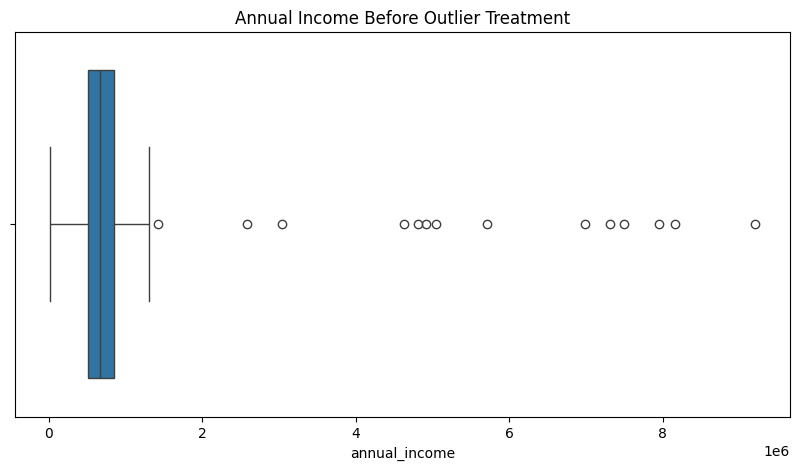

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=df['annual_income'])

plt.title('Annual Income Before Outlier Treatment')
plt.show()

In [33]:
df_z = df[
    ~(z_scores > 3).any(axis=1)
]

In [34]:
Q1 = df['annual_income'].quantile(0.25)

Q3 = df['annual_income'].quantile(0.75)

IQR = Q3 - Q1

In [35]:
lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

In [36]:
df_iqr = df[
    (df['annual_income'] >= lower)
    &
    (df['annual_income'] <= upper)
]

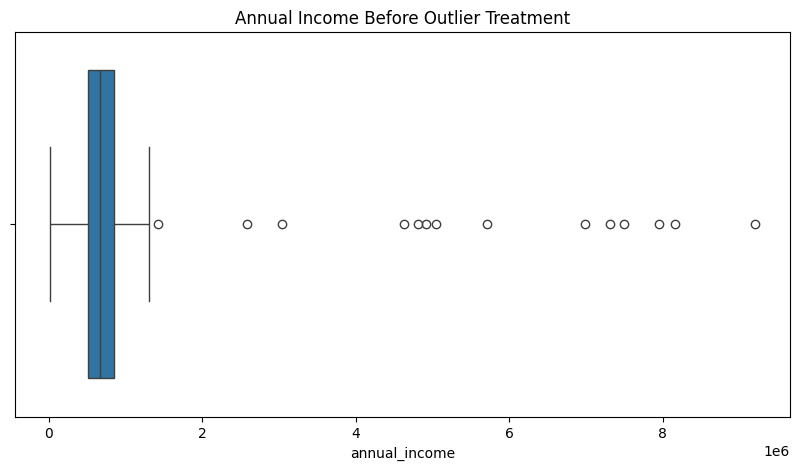

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=df['annual_income'])

plt.title('Annual Income Before Outlier Treatment')
plt.show()

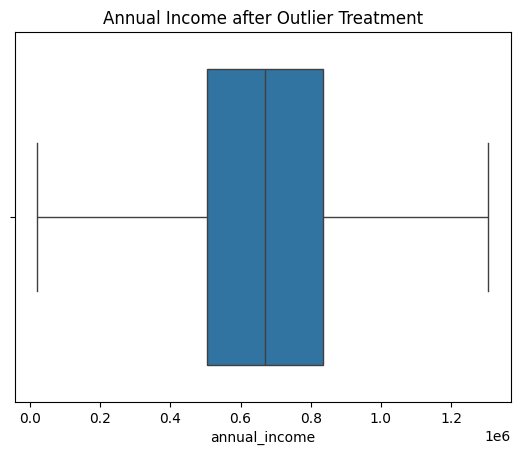

In [38]:
sns.boxplot(
    x=df_iqr['annual_income']
)
plt.title('Annual Income after Outlier Treatment')

plt.show()

###
Encoding
###

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(
    df['gender']
)

In [40]:
df = pd.get_dummies(
    df,
    columns=['loan_purpose'],
    drop_first=True
)

In [45]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Primary', 'Secondary', 'Graduate', 'Post-Graduate']])
df[['education_level']] = oe.fit_transform(df[['education_level']])


Scaling

In [48]:
'''StandardScaler'''

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(
    df[num_cols]
)



In [50]:
'''MinMaxScaler'''
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

df[num_cols] = mm.fit_transform(
    df[num_cols]
)

## PART G : FEATURE CONSTRUCTION & TRANSFORMATION


In [51]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

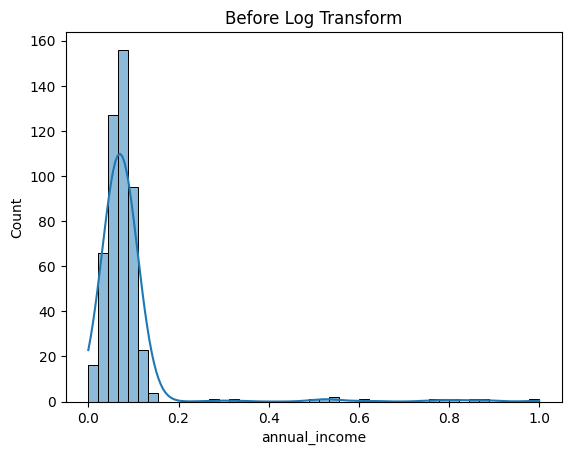

6.285109103031982


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['annual_income'],kde=True)

plt.title("Before Log Transform")
plt.show()
print(df['annual_income'].skew())


In [53]:
log_transformer = FunctionTransformer(
    np.log1p,
    validate=True
)

df['annual_income_log'] = log_transformer.fit_transform(
    df[['annual_income']]
)

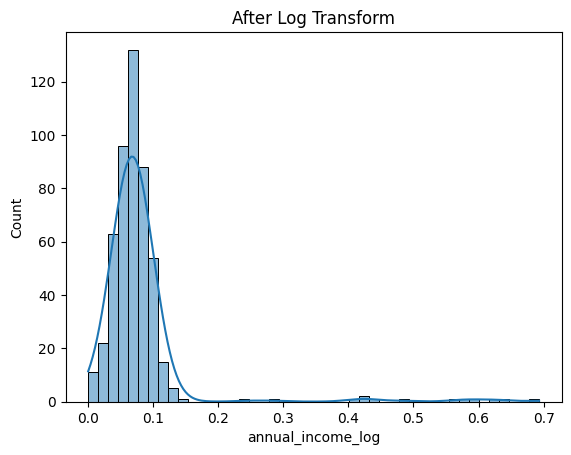

5.640104005223402


In [57]:
sns.histplot(df['annual_income_log'],kde=True)

plt.title("After Log Transform")
plt.show()

print(df['annual_income_log'].skew())

### A. Debt-To-Income Ratio

In [58]:
df['debt_to_income_ratio'] = (
    df['loan_amount']
    /
    df['annual_income']
)

## Spending-To-Income Ratio

In [59]:
df['spending_to_income_ratio'] = (
    df['spending_ratio']
    / 100
)

In [60]:
df[[
    'debt_to_income_ratio',
    'spending_to_income_ratio'
]].head()

,debt_to_income_ratio,spending_to_income_ratio
0,1.114842,0.001634
1,1.436406,0.005101
2,0.295827,0.004851
3,0.866756,0.006237
4,1.456066,0.009473


In [61]:
print(df.shape)

df.head()

(500, 26)


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,...,join_day,join_weekday,annual_income_missing,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,annual_income_log,debt_to_income_ratio,spending_to_income_ratio
0,CUST1000,0.863636,1,North,2.0,Salaried,0.042065,0.046896,0.738571,0.285714,...,3,Sunday,0,False,False,True,False,0.041205,1.114842,0.001634
1,CUST1001,0.636364,0,East,3.0,Salaried,0.020296,0.029154,0.608857,0.000000,...,20,Friday,0,False,False,False,False,0.020093,1.436406,0.005101
2,CUST1002,0.318182,1,East,0.0,NaN,0.090494,0.026771,0.428571,0.142857,...,27,Tuesday,0,False,False,False,False,0.086631,0.295827,0.004851
3,CUST1003,0.954545,1,West,0.0,Salaried,0.091822,0.079587,0.646571,0.142857,...,7,Sunday,0,False,False,False,False,0.087848,0.866756,0.006237
4,CUST1004,0.159091,1,West,2.0,Salaried,0.045197,0.065809,0.627143,0.000000,...,16,Thursday,0,False,True,False,False,0.044205,1.456066,0.009473


In [67]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
region                      0
education_level             0
employment_type             0
annual_income               0
loan_amount                 0
credit_score                0
repayment_history           0
transaction_count           0
spending_ratio              0
join_date                   0
default_flag                0
join_year                   0
join_month                  0
join_day                    0
join_weekday                0
annual_income_missing       0
loan_purpose_Car            0
loan_purpose_Education      0
loan_purpose_Home           0
loan_purpose_Other          0
annual_income_log           0
debt_to_income_ratio        0
spending_to_income_ratio    0
dtype: int64

In [69]:
df.to_csv(
    "Final_Credit_Risk_Dataset.csv",
    index=False
)


